Скачивание 5-минутных данных...
Расчет дневной реализованной волатильности...
Сохранена таблица: btc_realized_volatility.csv
Количество дней в итоговой выборке: 182
Построение графика...


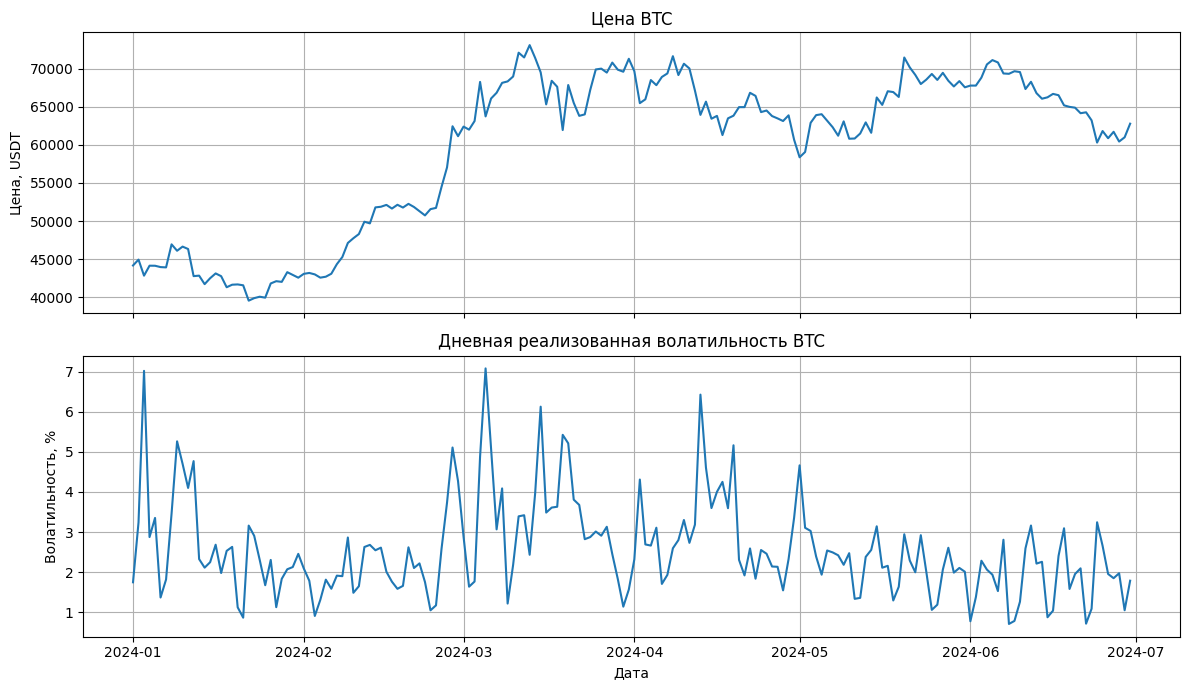

График сохранен: btc_volatility_example.png


In [ ]:
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SYMBOL = "BTCUSDT"
INTERVAL = "5m"

START_DATE = "2024-01-01"
END_DATE = "2024-07-01"

MIN_DAY_COVERAGE = 0.95  # минимум 95% 5-минутных точек за сутки
OUTPUT_IMAGE = "btc_volatility_example.png"
OUTPUT_CSV = "btc_realized_volatility.csv"


def to_milliseconds(date_str: str) -> int:
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)


def download_binance_klines(symbol: str, interval: str, start_date: str, end_date: str) -> pd.DataFrame:
    url = "https://api.binance.com/api/v3/klines"

    start_ms = to_milliseconds(start_date)
    end_ms = to_milliseconds(end_date)

    all_rows = []
    current_start = start_ms

    while current_start < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": 1000
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        data = response.json()

        if not data:
            break

        all_rows.extend(data)

        last_open_time = data[-1][0]
        current_start = last_open_time + 1

        time.sleep(0.2)

    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]

    df = pd.DataFrame(all_rows, columns=columns)

    df["datetime"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close"] = df["close"].astype(float)

    df = df[["datetime", "close"]]
    df = df.drop_duplicates(subset="datetime")
    df = df.sort_values("datetime")
    df = df.set_index("datetime")

    return df

def calculate_daily_realized_volatility(df_5m: pd.DataFrame) -> pd.DataFrame:
    # Сколько реальных 5-минутных точек было в каждом дне
    raw_points_per_day = df_5m["close"].resample("1D").count()

    # Полная 5-минутная сетка
    full_index = pd.date_range(
        start=df_5m.index.min().floor("D"),
        end=df_5m.index.max().ceil("D"),
        freq="5min",
        tz="UTC"
    )

    df = df_5m.reindex(full_index)

    # Заполнение пропусков методом forward fill
    df["close"] = df["close"].ffill()

    # Логарифмические доходности
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # Дневная реализованная дисперсия RV_t
    daily_rv = (df["log_return"] ** 2).resample("1D").sum()

    # Дневная реализованная волатильность sigma_t
    daily_sigma = np.sqrt(daily_rv)

    # Дневная цена close
    daily_close = df["close"].resample("1D").last()

    result = pd.DataFrame({
        "close": daily_close,
        "RV": daily_rv,
        "sigma": daily_sigma,
        "raw_5m_points": raw_points_per_day
    })

    # Оставляем только дни, где достаточно исходных 5-минутных точек
    min_points = int(288 * MIN_DAY_COVERAGE)
    result = result[result["raw_5m_points"] >= min_points]

    # Убираем возможные пустые значения
    result = result.dropna()

    return result

def plot_price_and_volatility(daily_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(daily_df.index, daily_df["close"])
    axes[0].set_title("Цена BTC")
    axes[0].set_ylabel("Цена, USDT")
    axes[0].grid(True)

    axes[1].plot(daily_df.index, daily_df["sigma"] * 100)
    axes[1].set_title("Дневная реализованная волатильность BTC")
    axes[1].set_ylabel("Волатильность, %")
    axes[1].set_xlabel("Дата")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    print("Скачивание 5-минутных данных...")
    df_5m = download_binance_klines(SYMBOL, INTERVAL, START_DATE, END_DATE)

    print("Расчет дневной реализованной волатильности...")
    daily_df = calculate_daily_realized_volatility(df_5m)

    daily_df.to_csv(OUTPUT_CSV, encoding="utf-8-sig")

    print(f"Сохранена таблица: {OUTPUT_CSV}")
    print(f"Количество дней в итоговой выборке: {len(daily_df)}")

    print("Построение графика...")
    plot_price_and_volatility(daily_df)

    print(f"График сохранен: {OUTPUT_IMAGE}")